In [2]:
import numpy as np
import healpy as hp
from matplotlib import pyplot as plt

import pymaster as nmt
import sys
sys.path.append('../')
from scripts.true_cmb import true_cmb
from scripts.gen_sims import gen_sims
from scripts.cosine_smoothed_mask import cosine_smoothed_mask
from scripts.apply_HILC import apply_HILC

In [3]:
nside=128
npix=hp.nside2npix(nside)
nsims=100
lmax=3*nside -1 
almsize=hp.Alm.getsize(lmax)
ells =np.arange(lmax+1)
print(ells.shape)
norm= (ells*(ells+1))/(2*np.pi)

(384,)


In [4]:
mask= cosine_smoothed_mask(nside)
mask= (mask*(-1))+1

In [84]:
cmb_th= (true_cmb())/norm[2:]

/home/iloveorcas/Internship_Rome/tests/../scripts/true_cmb.py:11: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=382`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  cl_th = np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))


In [6]:
def gen_raw_cmb(cl,nsims,nside):
    """Gnere

    Args:
        cl (_type_): _description_
        nsims (_type_): _description_
        nside (_type_): _description_

    Returns:
        _type_: _description_
    """
    cmb_raw=[]
    cl_raw=[]
    npix = hp.nside2npix(nside)
    
    for i in range(nsims):
        np.random.seed(i)
        cl_raw.append(hp.alm2cl(hp.synalm(cl)))
        alm=hp.synalm(cl)
        cmb_raw.append(hp.alm2map(alm, nside))
        
    cmb_raw = np.array(cmb_raw)
    cl_raw = np.array(cl_raw)
    """cmb_raw=np.tile(cmb_raw, (1, 7))
    cmb_raw = cmb_raw.reshape(nsims, 7, npix)"""
    return cmb_raw, cl_raw

In [85]:
map, _=gen_raw_cmb(cmb_th, nsims, nside)

In [7]:
map_pysm= gen_sims(nsims)

In [17]:
np.save("pysm_gen_cmb.npy", map_pysm)

In [9]:
map_pysm=np.load("/home/iloveorcas/Internship_Rome/results/pysm_gen_cmb.npy")

In [10]:
pysm_mean=np.mean(map_pysm,axis=0)
print(pysm_mean.shape)


(7, 196608)


In [86]:
map_mean=np.mean(map,axis=0)
print(map_mean.shape)

(196608,)


In [92]:
cl_mean2=hp.anafast(map_mean, lmax=381)

In [13]:
cl_pysm=hp.anafast(pysm_mean[0])

In [14]:
f_pysm=nmt.NmtField(1-mask, [pysm_mean[0]])
b=nmt.NmtBin.from_nside_linear(nside,1)
cl_pysm_dec = nmt.compute_full_master(f_pysm, f_pysm, b)

In [93]:
f=nmt.NmtField(1-mask, [map_mean])
b=nmt.NmtBin.from_nside_linear(nside,1)


In [ ]:
cl_00 = nmt.compute_full_master(f, f, b)

In [33]:
np.save("cl_pysm_dec.npy", cl_pysm_dec)
np.save("cl_self_dec.npy", cl_00)

In [17]:
f_sky = np.mean(mask)  # Mean of the mask gives the sky fraction


In [69]:
print(cl_mean2[2:300].shape)

(298,)


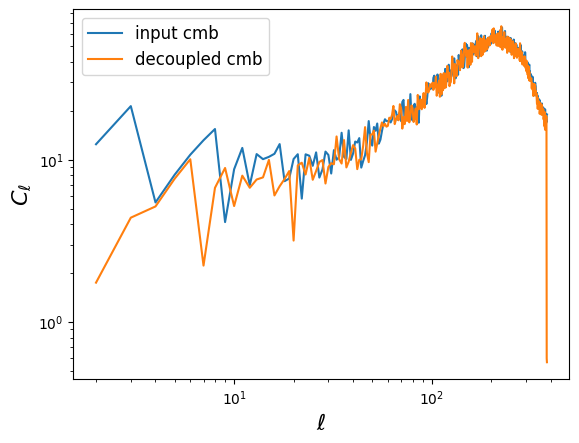

In [99]:
plt.plot(ells[2:], norm[2:]*cl_mean2, label='input cmb')
plt.plot(ells[2:], norm[2:]*cl_00[0], label='decoupled cmb')
#plt.plot(ells[2:], norm[2:]*cl_pysm[2:], label='input cmb pysm')
#plt.plot(ells[2:], norm[2:]*cl_pysm_dec[0], label='decoupled cmb pysm')

plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize=12)
plt.show()

In [76]:
bias_pysm= (cl_mean2[2: ]-cl_00[0])/cl_00
bias_gen= (cl_pysm_dec[0]-cl_pysm[2:])/cl_pysm[2:]


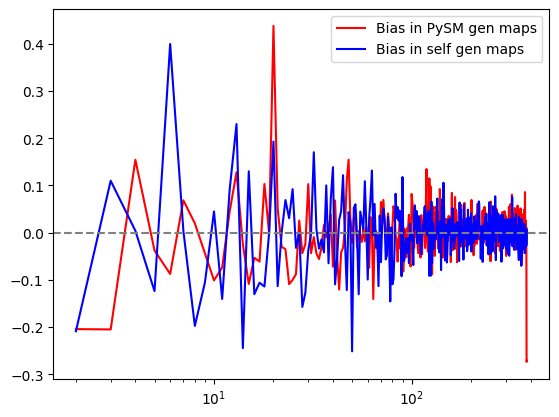

In [77]:
plt.plot(ells[2:], bias_pysm[0], label="Bias in PySM gen maps", color="red") 
plt.plot(ells[2:], bias_gen, label="Bias in self gen maps", color="blue") 
plt.axhline(0, linestyle="--", color="gray") 
plt.xscale("log")
plt.legend()
plt.show()

In [21]:
hilc_pysm= apply_HILC(pysm_mean)
hilc_cl1= nmt.compute_full_master(f_pysm,f_pysm,b)

In [22]:
map_mean=np.tile(map_mean, (1, 7))
map_mean = map_mean.reshape(7, npix)
print(map_mean.shape)

(7, 196608)


In [23]:
hilc_gen= apply_HILC(map_mean)
hilc_cl2= nmt.compute_full_master(f,f,b)

In [24]:
np.allclose(cl_pysm_dec, hilc_cl1)

True

In [25]:
np.allclose(hilc_cl2[0], cl_00)

True

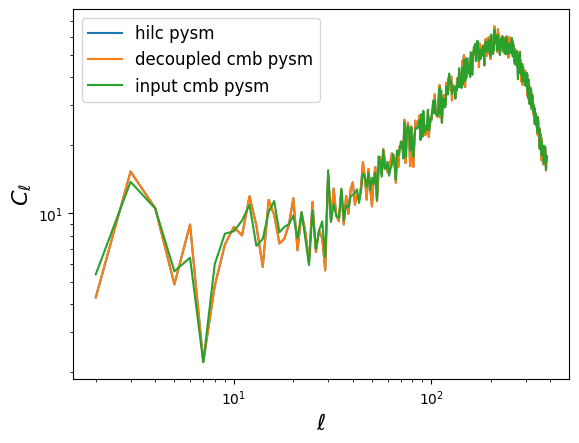

In [26]:
plt.plot(ells[2:], norm[2:]*hilc_cl1[0], label='hilc pysm')
plt.plot(ells[2:], norm[2:]*cl_pysm_dec[0], label='decoupled cmb pysm')
plt.plot(ells[2:], norm[2:]*cl_pysm[2:], label='input cmb pysm')

plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize=12)
plt.show()

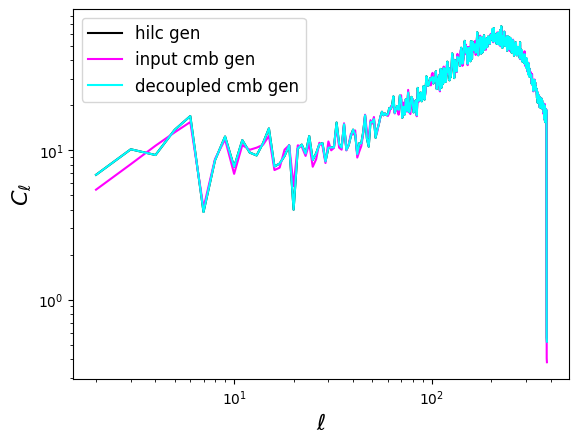

In [ ]:
plt.plot(ells[2:], hilc_cl2[0], label='hilc gen', color="black")
plt.plot(ells[2:], cl_mean2[2:], label='input cmb gen', color="magenta")
plt.plot(ells[2:], cl_00[0], label='decoupled cmb gen', color="cyan")
# plt.plot(ells[2:], cmb_th, label='theoretical cmb', color="brown")
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize=12)
plt.show()

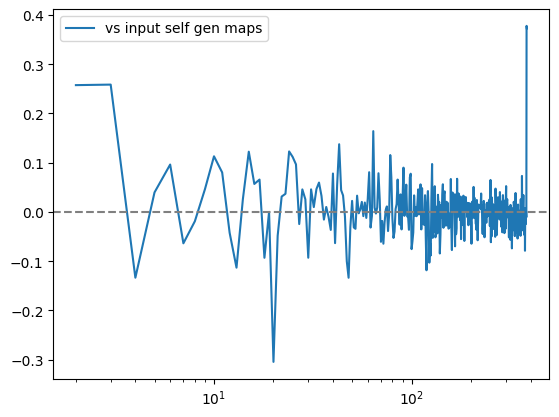

In [83]:
bias_hilc1= (hilc_cl1-cl_pysm[2:])/cl_pysm[2:]
bias_hilc2= (hilc_cl2-cl_mean2[2:])/cl_mean2[2:]
# plt.plot(ells[2:], bias_hilc1[0], label="vs input Pysm maps") 
plt.plot(ells[2:], bias_hilc2[0], label="vs input self gen maps") 

plt.axhline(0, linestyle="--", color="gray") 
plt.xscale("log")
# plt.title("Bias between the HILC and input Pysm maps")
plt.legend()
plt.show()